# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Model-model yang diminta soal
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

# Metrik Evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


## **EXPLORATORY DATA ANALYSIS (EDA)**

In [2]:
# Membaca dataset asli
df = pd.read_csv("Sales - Marketing customer dataset.csv")

print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

print("\n=== INFORMASI DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe(include='all'))

=== 5 BARIS PERTAMA DATASET ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  page

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,14262,13800.000000,15000,15000,15000,15000,15000,15000,15000,...,15000.000000,15000.000000,15000.000000,15000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,3,NaN,5,7,1000,800,5,3,2,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,...,NaN,NaN,NaN,UPI,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6844,NaN,3072,2236,29,32,3055,5043,7666,...,NaN,NaN,NaN,3105,NaN,NaN,NaN,NaN,NaN,NaN
mean,17500.500000,NaN,35.203913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.995600,0.147667,2.981333,NaN,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,NaN,10.334384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.421214,0.354781,1.720537,NaN,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,NaN,-4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,2.000000,NaN,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,0.000000,3.000000,NaN,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,0.000000,4.000000,NaN,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000


Persentase Nilai Kosong per Kolom:
 customer_id                    0.000000
gender                         4.920000
age                            8.000000
country                        0.000000
city                           0.000000
signup_date                    0.000000
last_purchase_date             0.000000
acquisition_channel            0.000000
device_type                    0.000000
subscription_type              0.000000
is_premium_user                0.000000
total_visits                   0.000000
avg_session_time               0.000000
pages_per_session              0.000000
email_open_rate                0.000000
email_click_rate               0.000000
total_spent                    7.000000
avg_order_value                0.000000
discount_used                  0.000000
coupon_code                   40.886667
support_tickets                0.000000
refund_requested               0.000000
delivery_delay_days            0.000000
payment_method                 0.000000
sati

/tmp/ipykernel_1006/3681013943.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Persentase_Kosong', y='Kolom', data=missing_df, palette='viridis')


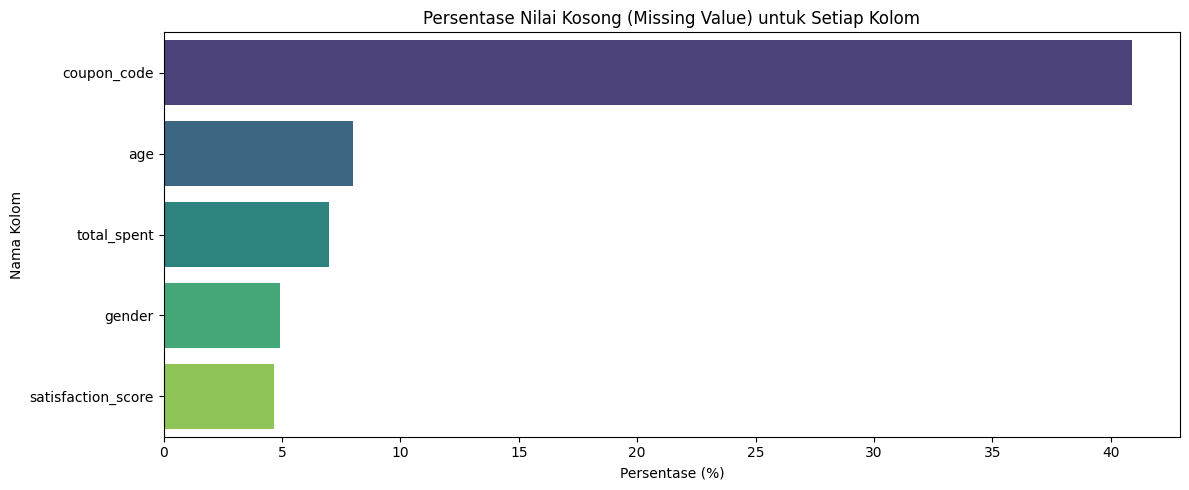

In [3]:
# Menghitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Kolom': df.columns, 'Persentase_Kosong': missing_percentage})
missing_df = missing_df[missing_df['Persentase_Kosong'] > 0].sort_values(by='Persentase_Kosong', ascending=False)

print("Persentase Nilai Kosong per Kolom:\n", missing_percentage)

# Visualisasi dengan Diagram Batang
plt.figure(figsize=(12, 5))
sns.barplot(x='Persentase_Kosong', y='Kolom', data=missing_df, palette='viridis')
plt.title('Persentase Nilai Kosong (Missing Value) untuk Setiap Kolom')
plt.xlabel('Persentase (%)')
plt.ylabel('Nama Kolom')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1006/2398010106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2')


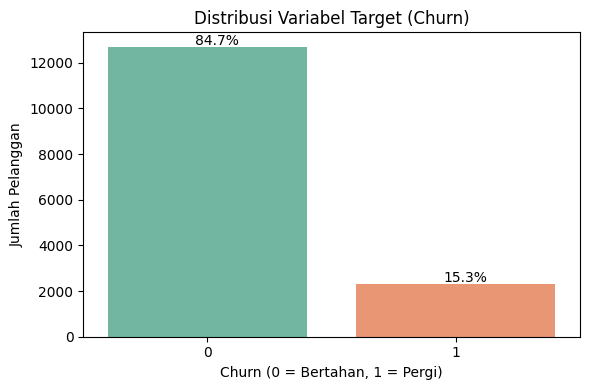

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn (0 = Bertahan, 1 = Pergi)')
plt.ylabel('Jumlah Pelanggan')

# Menampilkan persentase di atas batang grafik
total = len(df['churn'])
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 100
    plt.gca().annotate(percentage, (x, y))

plt.tight_layout()
plt.show()

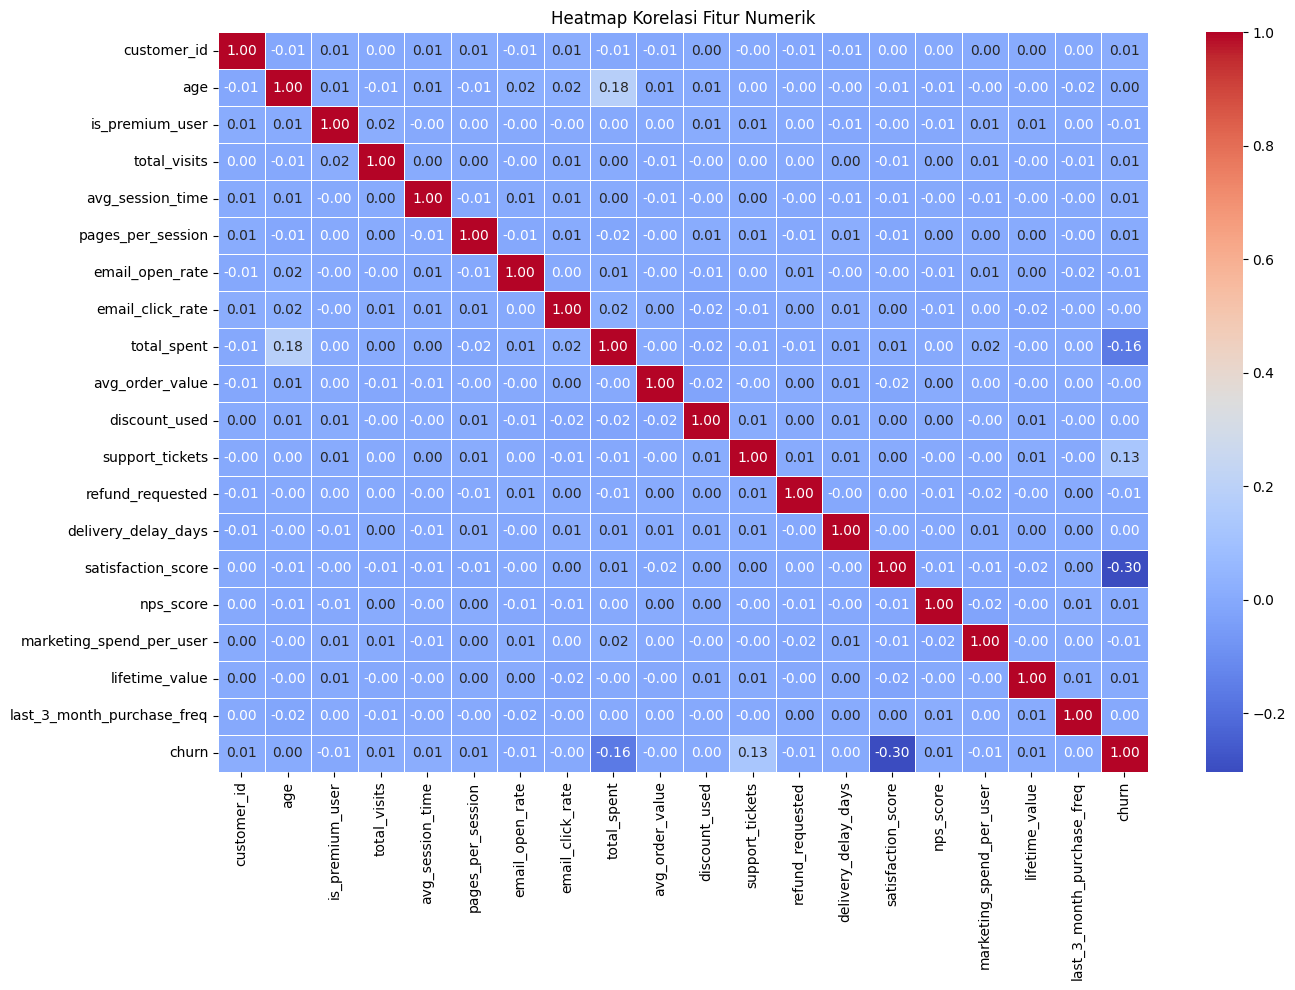

In [5]:
plt.figure(figsize=(14, 10))
# Mengambil kolom numerik saja untuk heatmap korelasi
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

**DIRECT MODELING (BASELINE EXPERIMENT)**

In [6]:
# Duplikat data untuk eksperimen direct modeling agar data asli tidak rusak
df_direct = df.copy()

# Sesuai instruksi soal: Seluruh kolom lain langsung digunakan sebagai fitur X, y adalah churn
X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

# Melakukan One-Hot Encoding kasar pada kolom non-numerik agar program tidak error saat fit
X_direct = pd.get_dummies(X_direct, drop_first=True)
# Mengisi sisa nilai kosong dengan angka 0 kasar (karena direct modeling dilarang pakai preprocessing ideal)
X_direct = X_direct.fillna(0)

# Train-test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct)
print("Split data Direct Modeling Sukses!")

Split data Direct Modeling Sukses!


In [7]:
# 1. Model Konvensional
model_lr = LogisticRegression(max_iter=1000, random_state=42)
# 2. Model Ensemble Bagging
model_rf = RandomForestClassifier(random_state=42)
# 3. Gabungan Model Konvensional (VotingClassifier)
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = KNeighborsClassifier()
model_voting = VotingClassifier(estimators=[('lr', clf1), ('knn', clf2)], voting='hard')

# List model untuk loop evaluasi
direct_models = {
    'Logistic Regression (Konvensional)': model_lr,
    'Random Forest (Bagging)': model_rf,
    'Voting Classifier (Gabungan)': model_voting
}

# Evaluasi
for name, model in direct_models.items():
    model.fit(X_train_d, y_train_d)
    y_pred_d = model.predict(X_test_d)

    print(f"\n==================== {name.upper()} ====================")
    print(f"Accuracy  : {accuracy_score(y_test_d, y_pred_d) * 100:.2f}%")
    print(f"Precision : {precision_score(y_test_d, y_pred_d, zero_division=0) * 100:.2f}%")
    print(f"Recall    : {recall_score(y_test_d, y_pred_d, zero_division=0) * 100:.2f}%")
    print(f"F1-Score  : {f1_score(y_test_d, y_pred_d, zero_division=0) * 100:.2f}%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_d, y_pred_d))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



==================== LOGISTIC REGRESSION (KONVENSIONAL) ====================
Accuracy  : 84.13%
Precision : 41.11%
Recall    : 8.04%
F1-Score  : 13.45%
Confusion Matrix:
[[2487   53]
 [ 423   37]]

==================== RANDOM FOREST (BAGGING) ====================
Accuracy  : 84.63%
Precision : 44.44%
Recall    : 0.87%
F1-Score  : 1.71%
Confusion Matrix:
[[2535    5]
 [ 456    4]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



==================== VOTING CLASSIFIER (GABUNGAN) ====================
Accuracy  : 84.97%
Precision : 90.91%
Recall    : 2.17%
F1-Score  : 4.25%
Confusion Matrix:
[[2539    1]
 [ 450   10]]


**MODELING DENGAN PREPROCESSING**

In [8]:
df_prep = df.copy()

# 1. Penghapusan Fitur Tidak Relevan (ID, Tanggal, Kupon) agar model tidak 100% Churn
kolom_dibuang = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_prep = df_prep.drop(columns=kolom_dibuang, errors='ignore')

# 2. Pembersihan Duplikasi data jika ada
df_prep = df_prep.drop_duplicates()

# 3. Penanganan Missing Value Mandiri (Imputasi Median & Modus)
num_cols = df_prep.select_dtypes(include=[np.number]).drop(columns=['churn'], errors='ignore').columns.tolist()
cat_cols = df_prep.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())
for col in cat_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

# 4. Penanganan Outlier Sederhana (Capping Menggunakan IQR pada kolom numerik)
for col in num_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_prep[col] = np.clip(df_prep[col], lower_bound, upper_bound)

print("Proses Data Cleaning dan Fitur Relevansi Selesai!")

Proses Data Cleaning dan Fitur Relevansi Selesai!


In [9]:
# Menetapkan kembali X dan y setelah data bersih
X_clean = df_prep.drop('churn', axis=1)
y_clean = df_prep['churn']

# Encoding Fitur Kategorikal menggunakan pd.get_dummies
X_clean_encoded = pd.get_dummies(X_clean, drop_first=True)

# Train-Test Split dengan proporsi 20% (Sama seperti Direct Modeling)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean_encoded, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# KUNCI ABSOLUT SCALING (Harus setelah splitting dilakukan sesuai instruksi soal)
scaler_prep = StandardScaler()
X_train_c_scaled = scaler_prep.fit_transform(X_train_c)
X_test_c_scaled = scaler_prep.transform(X_test_c) # Cukup transform pada data test

print("Split Data dan Scaling sesudah splitting sukses dilakukan!")

Split Data dan Scaling sesudah splitting sukses dilakukan!


In [10]:
# Menginisialisasi ulang model untuk data preprocessing
model_lr_p = LogisticRegression(max_iter=1000, random_state=42)
model_rf_p = RandomForestClassifier(random_state=42)

clf1_p = LogisticRegression(max_iter=1000, random_state=42)
clf2_p = KNeighborsClassifier()
model_voting_p = VotingClassifier(estimators=[('lr', clf1_p), ('knn', clf2_p)], voting='hard')

prep_models = {
    'Logistic Regression (Data Bersih)': model_lr_p,
    'Random Forest (Data Bersih)': model_rf_p,
    'Voting Classifier (Data Bersih)': model_voting_p
}

# Evaluasi Performa pasca preprocessing
for name, model in prep_models.items():
    model.fit(X_train_c_scaled, y_train_c)
    y_pred_c = model.predict(X_test_c_scaled)

    print(f"\n==================== {name.upper()} ====================")
    print(f"Accuracy  : {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")
    print(f"Precision : {precision_score(y_test_c, y_pred_c) * 100:.2f}%")
    print(f"Recall    : {recall_score(y_test_c, y_pred_c) * 100:.2f}%")
    print(f"F1-Score  : {f1_score(y_test_c, y_pred_c) * 100:.2f}%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_c, y_pred_c))


==================== LOGISTIC REGRESSION (DATA BERSIH) ====================
Accuracy  : 84.47%
Precision : 48.05%
Recall    : 16.09%
F1-Score  : 24.10%
Confusion Matrix:
[[2460   80]
 [ 386   74]]

==================== RANDOM FOREST (DATA BERSIH) ====================
Accuracy  : 84.70%
Precision : 50.26%
Recall    : 20.87%
F1-Score  : 29.49%
Confusion Matrix:
[[2445   95]
 [ 364   96]]

==================== VOTING CLASSIFIER (DATA BERSIH) ====================
Accuracy  : 84.93%
Precision : 78.57%
Recall    : 2.39%
F1-Score  : 4.64%
Confusion Matrix:
[[2537    3]
 [ 449   11]]


**FEATURE IMPORTANCE & HYPERPARAMETER TUNING**

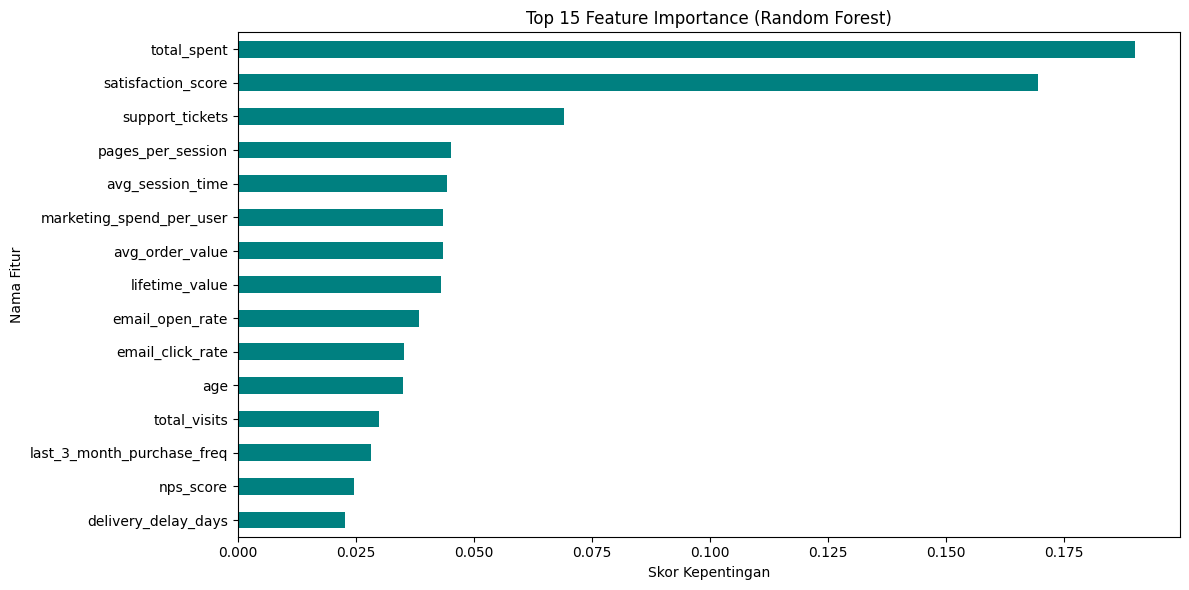

In [11]:
# Menghitung Feature Importance menggunakan model Random Forest yang sudah dilatih pada data bersih
importances = model_rf_p.feature_importances_
feature_names = X_clean_encoded.columns

feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Mengambil 15 fitur teratas untuk visualisasi agar rapi
plt.figure(figsize=(12, 6))
feat_importances.head(15).plot(kind='barh', color='teal').invert_yaxis()
plt.title('Top 15 Feature Importance (Random Forest)')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

In [12]:
print("Memulai Pencarian Konfigurasi Optimal via GridSearchCV...")

# 1. Menyusun parameter grid untuk Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 2. Menjalankan GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_c_scaled, y_train_c)

# 3. Memperoleh Best Estimator dan Best Parameter
best_rf_model = grid_search.best_estimator_

print("\n=== HASIL OPTIMALISASI TUNING ===")
print("Best Parameters:", grid_search.best_params_)

# 4. Mengevaluasi Performa Model Hasil Tuning Akhir
y_pred_final = best_rf_model.predict(X_test_c_scaled)

print(f"\nAccuracy Akhir  : {accuracy_score(y_test_c, y_pred_final) * 100:.2f}%")
print(f"Precision Akhir : {precision_score(y_test_c, y_pred_final) * 100:.2f}%")
print(f"Recall Akhir    : {recall_score(y_test_c, y_pred_final) * 100:.2f}%")
print(f"F1-Score Akhir  : {f1_score(y_test_c, y_pred_final) * 100:.2f}%")
print("\nConfusion Matrix Akhir:")
print(confusion_matrix(y_test_c, y_pred_final))

Memulai Pencarian Konfigurasi Optimal via GridSearchCV...

=== HASIL OPTIMALISASI TUNING ===
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Accuracy Akhir  : 84.83%
Precision Akhir : 51.05%
Recall Akhir    : 26.30%
F1-Score Akhir  : 34.72%

Confusion Matrix Akhir:
[[2424  116]
 [ 339  121]]


In [13]:
# 1. Simpan Model Terbaik Hasil Tuning
joblib.dump(best_rf_model, "best_model.pkl")

# 2. Simpan Objek Scaler Beres dari Data Training Bersih
joblib.dump(scaler_prep, "scaler.pkl")

# 3. Simpan Daftar Urutan Kolom Hasil Encoding Bersih
joblib.dump(X_clean_encoded.columns.tolist(), "columns.pkl")

print("SUKSES! File best_model.pkl, scaler.pkl, dan columns.pkl telah berhasil disimpan.")

SUKSES! File best_model.pkl, scaler.pkl, dan columns.pkl telah berhasil disimpan.
